# Energy Price Prediction Pipeline

This notebook implements a modular machine learning pipeline for predicting 24-hour ahead energy price movements using news signals and energy market data.

## Pipeline Stages
1. **Setup & Configuration** - Initialize system and configure compute
2. **Data Ingestion** - Load news and energy data
3. **News Processing** - Extract text features and embeddings
4. **Feature Engineering** - Time-decay aggregation and PCA
5. **Parameter Optimization** - Grid search over decay parameters
6. **Model Training** - Train XGBoost/LightGBM models
7. **Evaluation** - Performance assessment and statistical testing

## 1. Setup & Imports

In [10]:
# Add scripts directory to path
import sys
from pathlib import Path

# Navigate to scripts directory
scripts_dir = Path('../scripts').resolve()
config_dir = Path('../config').resolve()
sys.path.insert(0, str(scripts_dir.parent))

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Custom module imports
from config import pipeline_config as cfg
from config import model_config
from scripts import device_utils
from scripts import profiling
from scripts import data_ingestion
from scripts import feature_engineering as fe
from scripts import model_utils
from scripts import evaluation
from scripts import visualization

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All modules imported successfully")

✓ All modules imported successfully


## 2. Configure Parameters

**Customize these parameters to tune the pipeline behavior:**

In [11]:
# ============================================================================
# CONFIGURABLE PARAMETERS - MODIFY THESE AS NEEDED
# ============================================================================

# Time-series parameters
FORECAST_HORIZON = cfg.FORECAST_HORIZON_HOURS  # 24 hours
LOOKBACK_WINDOW = cfg.DEFAULT_LOOKBACK_WINDOW  # 336 hours (2 weeks)
TIME_DECAY_LAMBDA = cfg.DEFAULT_DECAY_LAMBDA   # 0.05

# Target definition
SPREAD_DEADBAND = cfg.SPREAD_TARGET_DEADBAND   # 5.0 EUR/MWh

# Data splits
TRAIN_RATIO = cfg.TRAIN_RATIO  # 0.7
VAL_RATIO = cfg.VAL_RATIO      # 0.2
TEST_RATIO = cfg.TEST_RATIO    # 0.1

# Feature engineering
PCA_COMPONENTS = cfg.PCA_COMPONENTS  # 50
USE_UMAP = True  # Use UMAP for dimensionality reduction (False = PCA only)

# Cross-validation
N_CV_SPLITS = cfg.N_CV_SPLITS  # 5
CV_STEP_SIZE = cfg.CV_STEP_SIZE_HOURS  # 24

# Grid search ranges
LOOKBACK_WINDOWS = cfg.LOOKBACK_WINDOWS  # [168, 336, 504]
TIME_DECAY_LAMBDAS = cfg.TIME_DECAY_LAMBDAS  # [0.01, 0.05, 0.1]

# Random search
XGB_RANDOM_SEARCH_ITERS = 40

# Data paths (relative to data directory)
NEWS_PATH = "../data/german_news_v1.csv"
ENERGY_PATH = "../data/energy_data.csv"

print("✓ Configuration loaded")
print(f"  Forecast horizon: {FORECAST_HORIZON} hours")
print(f"  Lookback window: {LOOKBACK_WINDOW} hours")
print(f"  Time decay lambda: {TIME_DECAY_LAMBDA}")
print(f"  Spread deadband: {SPREAD_DEADBAND} EUR/MWh")

✓ Configuration loaded
  Forecast horizon: 24 hours
  Lookback window: 336 hours
  Time decay lambda: 0.05
  Spread deadband: 5.0 EUR/MWh


## 3. Initialize System & Detect Compute Device

In [12]:
# Detect available compute device (GPU/CPU)
device_config = device_utils.detect_compute_device(task='general', verbose=True)

print(f"\n✓ Using device: {device_config['description']}")
print(f"  Optimal batch size: {device_config['optimal_batch_size']}")

✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)

✓ Using device: Apple MPS GPU
  Optimal batch size: 128


## 4. Stage 1: Data Ingestion

In [13]:
with profiling.StageProfiler("Stage 1: Data Ingestion", device_config):
    ingestion_results = data_ingestion.run_ingestion_stage(
        news_path=NEWS_PATH,
        energy_path=ENERGY_PATH,
        min_timestamp=cfg.MIN_TIMESTAMP,
        news_sample=100,  # Set to integer for testing with smaller dataset
        forecast_horizon=FORECAST_HORIZON,
        spread_deadband=SPREAD_DEADBAND,
        random_state=cfg.RANDOM_STATE,
    )

news_df = ingestion_results['news_df']
energy_df = ingestion_results['energy_df']
master_df = ingestion_results['master_df']

print(f"\n✓ Data loaded successfully")
print(f"  News articles: {len(news_df)}")
print(f"  Energy records: {len(energy_df)}")
print(f"  Master records: {len(master_df)}")


[Stage ⏳] Stage 1: Data Ingestion — starting
News shape after filters: (100, 4)
Energy telemetry shape: (7462, 5)
Baseline feature frame: (7270, 16)
[Stage ✅] Stage 1: Data Ingestion — completed in 1.24s
  CPU usage: 76.7% • IO wait: 0.00%
  Disk Δ: +11.9 MB read, +0.4 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Data loaded successfully
  News articles: 100
  Energy records: 7462
  Master records: 7270


### Inspect Data

In [14]:
# Check target distribution
print("Target distribution:")
print(master_df['spread_target_shift_24'].value_counts())
print(f"\nTarget distribution (%)")
print(master_df['spread_target_shift_24'].value_counts(normalize=True) * 100)

Target distribution:
spread_target_shift_24
-1.0    2971
 1.0    2859
 0.0    1440
Name: count, dtype: int64

Target distribution (%)
spread_target_shift_24
-1.0    40.866575
 1.0    39.325997
 0.0    19.807428
Name: proportion, dtype: float64


## 5. Stage 2: News Processing - Topic Classification

In [15]:
with profiling.StageProfiler("Stage 2A: Zero-Shot Topic Classification", device_config):
    embedding_results = fe.run_embedding_stage(
        news_df=news_df,
        candidate_labels=cfg.CANDIDATE_LABELS,
        hypothesis_template=cfg.HYPOTHESIS_TEMPLATE,
        device_config=device_config,
        batch_size=device_config['optimal_batch_size'],
        model_name=cfg.ZEROSHOT_MODEL,
    )

news_df = embedding_results['news_df']

print(f"\n✓ Topic classification completed")
print(f"  Device used: {embedding_results['hf_device']}")
print(f"  Batch size: {embedding_results['batch_size']}")


[Stage ⏳] Stage 2A: Zero-Shot Topic Classification — starting


Device set to use mps


Processing 100 texts with batch_size=128
Classification completed: 100 articles processed
Articles classified as 'other': 0 (0.0%)

Classification distribution:
classification
Störungen oder Ausfälle bei Netzen oder Kraftwerken verringern das Angebot         46
die Großhandelspreise für Erdgas steigen                                           15
sinkende Zinsen oder nachlassende Inflation beruhigen die Marktlage                11
geopolitische Entspannung oder gelockerte Sanktionen mindern Versorgungsrisiken     8
die Stromerzeugung aus Wind und Sonne steigt                                        6
der Ausbau von LNG-Terminals, Pipelines oder Kraftwerken erhöht das Angebot         4
der Stromverbrauch in Deutschland steigt                                            4
der Stromverbrauch in Deutschland fällt                                             2
die Stromerzeugung aus Wind und Sonne fällt                                         2
die Großhandelspreise für Erdgas fallen           

## 6. Stage 2B: Sentence Embeddings

In [16]:
with profiling.StageProfiler("Stage 2B: Sentence Embeddings", device_config):
    news_df = fe.compute_embeddings(
        news_df=news_df,
        device_config=device_config,
        model_name=cfg.EMBEDDING_MODEL,
        batch_size=device_config['optimal_batch_size'],
        show_progress=True,
        cache_dir=Path('../outputs/.cache/embeddings'),
    )

print(f"\n✓ Embeddings computed")
print(f"  Embedding dimension: {len(news_df.iloc[0]['embedding'])}")


[Stage ⏳] Stage 2B: Sentence Embeddings — starting
Using batch_size=128 for embedding computation on device=mps


Batches: 100%|██████████| 1/1 [00:00<00:00,  3.72it/s]

Embeddings computed: shape (100, 384)
[Stage ✅] Stage 2B: Sentence Embeddings — completed in 5.88s
  CPU usage: 70.3% • IO wait: 0.00%
  Disk Δ: +651.8 MB read, +402.3 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Embeddings computed
  Embedding dimension: 384


## 7. Stage 3: Feature Engineering - Time-Decay Aggregation

In [17]:
with profiling.StageProfiler("Stage 3A: Time-Decayed Topic Counts", device_config):
    td_topics_df = fe.compute_time_decayed_topic_counts(
        news_df=news_df,
        master_df=master_df,
        lookback_window=LOOKBACK_WINDOW,
        decay_lambda=TIME_DECAY_LAMBDA,
        verbose=True,
    )

print(f"\n✓ Time-decayed topic counts computed")
print(f"  Shape: {td_topics_df.shape}")
print(f"  Topics: {td_topics_df.columns.tolist()}")


[Stage ⏳] Stage 3A: Time-Decayed Topic Counts — starting
Computing time-decayed counts for 7270 timestamps and 11 topics
Lookback window: 336h, decay lambda: 0.05
Using vectorized computation for improved performance...
Processing 100 valid articles across 7270 timestamps


Processing timestamps: 100%|██████████| 7270/7270 [00:00<00:00, 17420.31it/s]

[Stage ✅] Stage 3A: Time-Decayed Topic Counts — completed in 0.42s
  CPU usage: 0.0% • IO wait: 0.00%
  Disk Δ: +13.3 MB read, +0.4 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Time-decayed topic counts computed
  Shape: (7270, 11)
  Topics: ['die Großhandelspreise für Erdgas steigen', 'Störungen oder Ausfälle bei Netzen oder Kraftwerken verringern das Angebot', 'sinkende Zinsen oder nachlassende Inflation beruhigen die Marktlage', 'der Stromverbrauch in Deutschland fällt', 'der Ausbau von LNG-Terminals, Pipelines oder Kraftwerken erhöht das Angebot', 'geopolitische Entspannung oder gelockerte Sanktionen mindern Versorgungsrisiken', 'die Stromerzeugung aus Wind und Sonne steigt', 'der Stromverbrauch in Deutschland steigt', 'die Großhandelspreise für Erdgas fallen', 'die Stromerzeugung aus Wind und Sonne fällt', 'steigende Zinsen oder hohe Inflation verschärfen die Marktlage']


In [18]:
with profiling.StageProfiler("Stage 3B: Time-Decayed Embeddings", device_config):
    weighted_embeddings = fe.compute_time_decayed_embeddings(
        news_df=news_df,
        master_df=master_df,
        lookback_window=LOOKBACK_WINDOW,
        decay_lambda=TIME_DECAY_LAMBDA,
        verbose=True,
    )

print(f"\n✓ Time-decayed embeddings computed")
print(f"  Shape: {weighted_embeddings.shape}")


[Stage ⏳] Stage 3B: Time-Decayed Embeddings — starting
Computing time-decayed weighted average embeddings for 7270 timestamps
Lookback window: 336h, decay lambda: 0.05
Using optimized vectorized computation...
Processing 100 valid embeddings across 7270 timestamps
Using binary search for efficient article lookup...


Processing timestamps: 100%|██████████| 7270/7270 [00:00<00:00, 95418.16it/s]


Completed time-decayed aggregation
Embedding shape: (7270, 384)
[Stage ✅] Stage 3B: Time-Decayed Embeddings — completed in 0.08s
  CPU usage: 0.0% • IO wait: 0.00%
  Disk Δ: +0.7 MB read, +0.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Time-decayed embeddings computed
  Shape: (7270, 384)


## 8. Stage 3C: Dimensionality Reduction

In [19]:
with profiling.StageProfiler("Stage 3C: Embedding Dimensionality Reduction", device_config):
    # Handle NaN values before reduction
    nan_mask = np.isnan(weighted_embeddings).any(axis=1)
    weighted_embeddings_clean = weighted_embeddings.copy()
    weighted_embeddings_clean[nan_mask] = 0.0
    
    td_embeddings_df = fe.reduce_embeddings_gpu_first(
        embeddings=weighted_embeddings_clean,
        index=master_df.index,
        cache_label=f'td_embeddings_lw{LOOKBACK_WINDOW}_dl{TIME_DECAY_LAMBDA}',
        n_components=PCA_COMPONENTS,
        use_umap=USE_UMAP,
        random_state=cfg.RANDOM_STATE,
    )

print(f"\n✓ Dimensionality reduction completed")
print(f"  Reduced shape: {td_embeddings_df.shape}")


[Stage ⏳] Stage 3C: Embedding Dimensionality Reduction — starting
Embedding reduction backend: umap-learn
[Stage ✅] Stage 3C: Embedding Dimensionality Reduction — completed in 24.09s
  CPU usage: 75.8% • IO wait: 0.00%
  Disk Δ: +578.7 MB read, +414.3 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Dimensionality reduction completed
  Reduced shape: (7270, 50)


## 9. Merge Features and Create Train/Val/Test Splits

In [20]:
# Merge all features
feature_df = master_df.copy()
feature_df = feature_df.join(td_topics_df)
feature_df = feature_df.join(td_embeddings_df)

# Remove rows with NaN in target
feature_df = feature_df.dropna(subset=[cfg.TARGET_COLUMN])

print(f"✓ Features merged")
print(f"  Total features: {feature_df.shape[1]}")
print(f"  Total samples: {feature_df.shape[0]}")

# Create splits
n_samples = len(feature_df)
train_end = int(n_samples * TRAIN_RATIO)
val_end = int(n_samples * (TRAIN_RATIO + VAL_RATIO))

train_df = feature_df.iloc[:train_end]
val_df = feature_df.iloc[train_end:val_end]
test_df = feature_df.iloc[val_end:]

print(f"\n✓ Data splits created")
print(f"  Train: {len(train_df)} samples ({len(train_df)/n_samples*100:.1f}%)")
print(f"  Val:   {len(val_df)} samples ({len(val_df)/n_samples*100:.1f}%)")
print(f"  Test:  {len(test_df)} samples ({len(test_df)/n_samples*100:.1f}%)")

✓ Features merged
  Total features: 77
  Total samples: 7270

✓ Data splits created
  Train: 5089 samples (70.0%)
  Val:   1453 samples (20.0%)
  Test:  728 samples (10.0%)


## 10. Define Feature Sets

In [21]:
# Baseline features (price + temporal)
baseline_features = [
    'Spot Price', 'Day Ahead Auction', 'real_spread_abs',
    'price_lag_24', 'price_lag_168',
    'Load', 'load_lag_24', 'load_lag_168',
    'hour', 'day_of_week', 'day_of_year', 'week_of_year', 'month'
]

# News features (topics + embeddings)
topic_features = td_topics_df.columns.tolist()
embedding_features = td_embeddings_df.columns.tolist()
news_features = topic_features + embedding_features

# All features
all_features = baseline_features + news_features

print(f"✓ Feature sets defined")
print(f"  Baseline features: {len(baseline_features)}")
print(f"  Topic features: {len(topic_features)}")
print(f"  Embedding features: {len(embedding_features)}")
print(f"  Total features: {len(all_features)}")

✓ Feature sets defined
  Baseline features: 13
  Topic features: 11
  Embedding features: 50
  Total features: 74


## 11. Stage 4: Model Training - XGBoost with Random Search

**Note:** This section demonstrates XGBoost training with hyperparameter tuning. Adjust `n_iter` and CV parameters based on your computational resources.

In [22]:
with profiling.StageProfiler("Stage 4: XGBoost Random Search", device_config):
    # Prepare data dict for random search
    data_dict = {
        'train_df': train_df,
        'scaled_news_features': news_features,
    }
    
    # Run random search
    search_results, feature_columns = model_utils.run_xgb_random_search(
        data_dict=data_dict,
        baseline_features=baseline_features,
        target_column=cfg.TARGET_COLUMN,
        param_distributions=cfg.XGB_PARAM_DISTRIBUTIONS,
        n_iter=XGB_RANDOM_SEARCH_ITERS,
        random_state=cfg.RANDOM_STATE,
        n_splits=cfg.DEFAULT_EXPANDING_SPLITS,
        step_size=cfg.DEFAULT_EXPANDING_STEP,
        min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
        device_config=device_config,
    )

print(f"\n✓ Random search completed")
print(f"  Best score: {search_results.best_score_:.4f}")
print(f"  Best params: {search_results.best_params_}")


[Stage ⏳] Stage 4: XGBoost Random Search — starting
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 4 folds for each of 40 candidates, totalling 160 fits


/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:11:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:11:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:11:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:11:50] WARNING: /Users/runner/work/xgboost/xgboost/src/lear

[Stage ✅] Stage 4: XGBoost Random Search — completed in 20.98s
  CPU usage: 95.5% • IO wait: 0.00%
  Disk Δ: +804.9 MB read, +1583.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Random search completed
  Best score: 0.7012
  Best params: {'colsample_bytree': np.float64(0.9849789179768444), 'gamma': np.float64(1.2589114791268208), 'learning_rate': np.float64(0.05426206745606973), 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 280, 'reg_alpha': np.float64(0.002157272818260383), 'reg_lambda': np.float64(76.39673162610626), 'subsample': np.float64(0.7644148053272926)}


## 12. Stage 5: Model Evaluation

In [23]:
# Get best model
best_model = search_results.best_estimator_

# Prepare test data
X_test = test_df[feature_columns].fillna(0)
y_test = test_df[cfg.TARGET_COLUMN].astype(int)

# Make predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

# Compute metrics
from sklearn.metrics import accuracy_score, classification_report

test_accuracy = accuracy_score(y_test, y_pred)

print(f"\n✓ Model Evaluation")
print(f"  Test Accuracy: {test_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))


✓ Model Evaluation
  Test Accuracy: 0.2885

Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       245
           0       0.26      0.81      0.39       198
           1       0.45      0.18      0.25       285

    accuracy                           0.29       728
   macro avg       0.24      0.33      0.22       728
weighted avg       0.25      0.29      0.21       728



/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

## 13. Visualizations

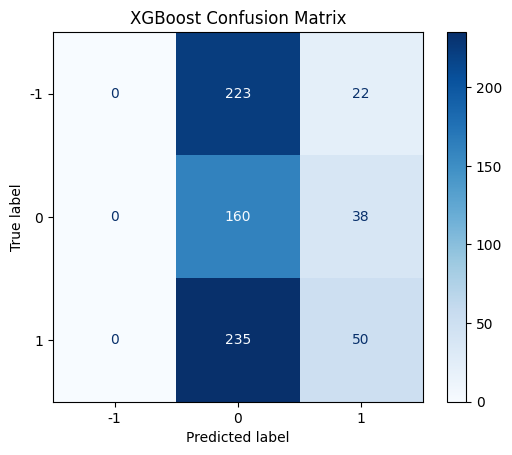

In [24]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 0, 1])
disp.plot(cmap='Blues', values_format='d')
plt.title('XGBoost Confusion Matrix')
plt.show()

/Users/nicolas/Desktop/Repos/zhaw_arep/final_methodology_refactored/scripts/visualization.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


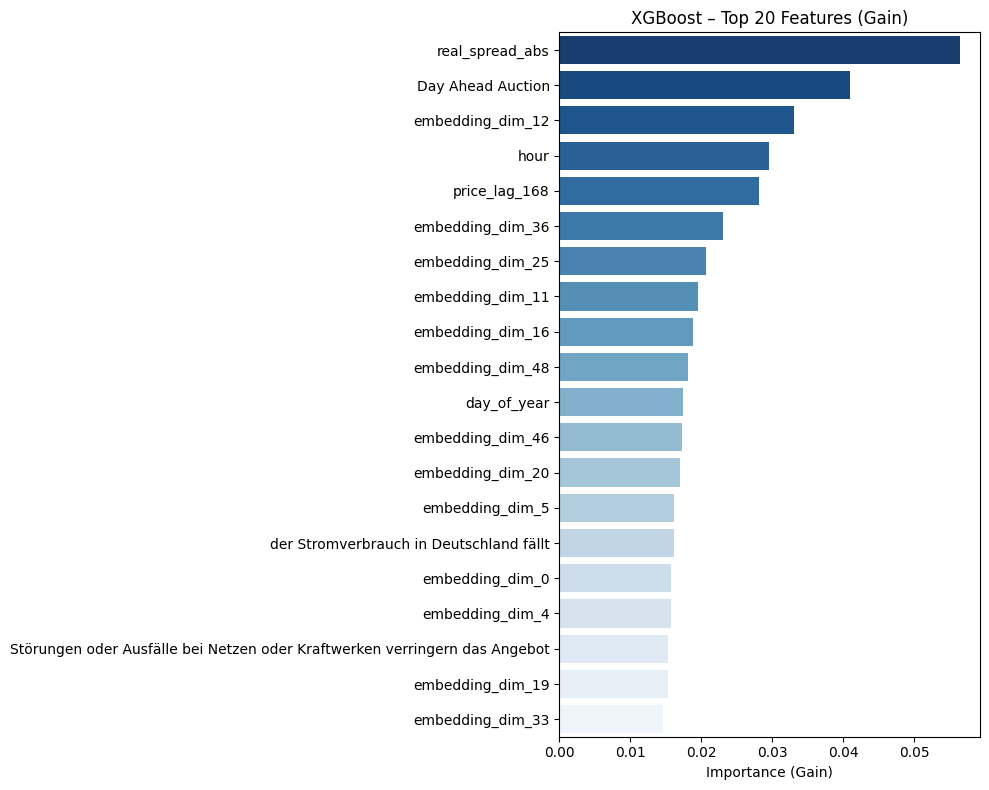

In [25]:
# Feature importance
importance_df = visualization.plot_feature_importance(
    model=best_model,
    feature_names=feature_columns,
    model_name="XGBoost",
    top_n=20
)

## 14. Save Results (Optional)

In [26]:
# Save model
import joblib
from datetime import datetime

output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_path = output_dir / f'xgb_model_{timestamp}.joblib'

joblib.dump(best_model, model_path)
print(f"✓ Model saved to: {model_path}")

✓ Model saved to: ../outputs/xgb_model_20251111_211204.joblib


## Summary

This notebook demonstrates the complete pipeline for energy price prediction:

1. ✅ Loaded and preprocessed news and energy data
2. ✅ Classified news articles using zero-shot learning
3. ✅ Computed sentence embeddings
4. ✅ Applied time-decay aggregation to news signals
5. ✅ Trained XGBoost model with hyperparameter tuning
6. ✅ Evaluated model performance

**Next Steps:**
- Experiment with different time-decay parameters (λ, lookback window)
- Try different dimensionality reduction techniques (UMAP vs PCA)
- Compare with baseline models (price-only)
- Perform statistical significance testing
- Train LightGBM models for comparison